# EDA and Text Preprocessing - Urgency Classification

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Deteksi apakah berjalan di Google Colab atau lokal
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research'
    if not os.path.exists(PROJECT_ROOT):
        PROJECT_ROOT = '/content/drive/MyDrive/lentera-ml-research'
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan di Google Colab. Direktori aktif saat ini: {os.getcwd()}")
else:
    # Berjalan secara lokal (VS Code / Jupyter Notebook)
    notebook_dir = os.getcwd()
    if os.path.basename(notebook_dir) == 'notebooks':
        PROJECT_ROOT = os.path.abspath(os.path.join(notebook_dir, '..'))
    else:
        if os.path.exists(os.path.join(notebook_dir, 'notebooks')):
            PROJECT_ROOT = notebook_dir
        else:
            PROJECT_ROOT = os.path.abspath(os.path.join(notebook_dir, '..'))
    os.chdir(PROJECT_ROOT)
    print(f"Berjalan secara lokal. Project root: {PROJECT_ROOT}")

# Memasukkan direktori root proyek ke dalam sistem pencarian modul Python
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Styling for plots
sns.set_theme(style="whitegrid")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Berjalan di Google Colab. Direktori aktif saat ini: /content/drive/MyDrive/lentera-analytics-hub/lentera-ml-research


## 1. Load Data

In [3]:
dataset_path = 'data/raw/complaints-2026-05-20_09_21.csv'
df = pd.read_csv(dataset_path)
print(f"Shape of dataset: {df.shape}")
df.head(2)

Shape of dataset: (53928, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,03/17/26,Debt collection,Auto debt,Written notification about debt,Didn't receive notice of right to dispute,I started getting emails and telephone calls f...,NaN,"The Bureaus, Inc.",GA,30518,NaN,Consent provided,Web,03/17/26,Closed with explanation,Yes,NaN,20323715
1,03/05/26,Debt collection,Other debt,False statements or representation,Attempted to collect wrong amount,Date : XX/XX/XXXX To : XXXX XXXX Re : XXXXXXXX...,NaN,"CAINE & WEINER COMPANY, INC.",OR,973XX,NaN,Consent provided,Web,03/19/26,Closed with non-monetary relief,Yes,NaN,20012076


## 2. Pembersihan Data Awal

In [4]:
from src.preprocessing import filter_invalid_complaints

df = filter_invalid_complaints(df)
print(f"Dimensi data setelah pembersihan awal: {df.shape}")

Dimensi data setelah pembersihan awal: (53928, 19)


## 3. Auto Labeling Urgency

In [5]:
from src.preprocessing import apply_urgency_labels

df = apply_urgency_labels(df)

# Cek distribusi kelas
print("Distribusi Urgency:")
print(df['Urgency'].value_counts())

Distribusi Urgency:
Urgency
Medium    20953
High      20771
Low       12204
Name: count, dtype: int64


## 5. Text Preprocessing

In [6]:
from src.preprocessing import normalize_text_pipeline

df = normalize_text_pipeline(df)

## 4. Exploratory Data Analysis (EDA)

/tmp/ipykernel_11039/1184275637.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Urgency', data=df, order=['High', 'Medium', 'Low'], palette='viridis')


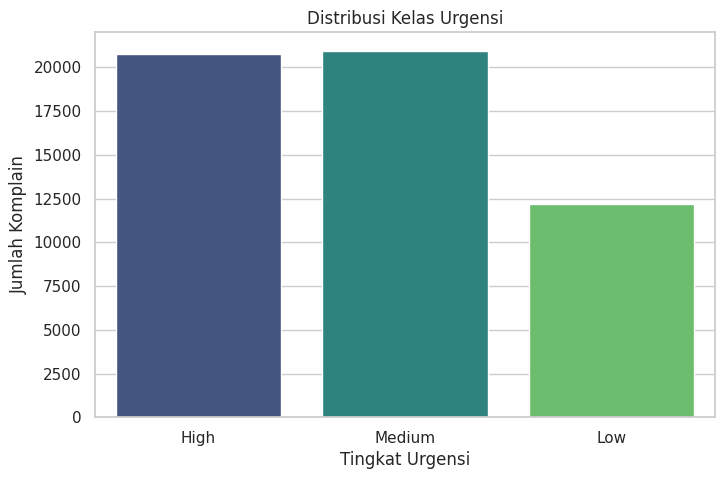

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Urgency', data=df, order=['High', 'Medium', 'Low'], palette='viridis')
plt.title('Distribusi Kelas Urgensi')
plt.ylabel('Jumlah Komplain')
plt.xlabel('Tingkat Urgensi')
plt.show()

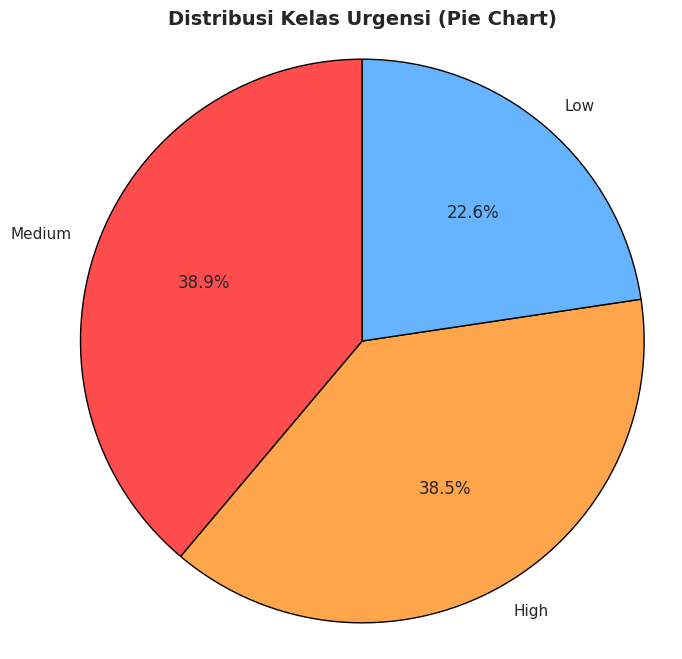

In [8]:
# Pie Chart Distribusi Kelas Urgensi
plt.figure(figsize=(8, 8))
class_counts = df['Urgency'].value_counts()
colors = ['#ff4d4d', '#ffa64d', '#66b3ff']
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Distribusi Kelas Urgensi (Pie Chart)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

### EDA Urgency dengan kolom "Company public response"

Membuat Plot EDA 1...


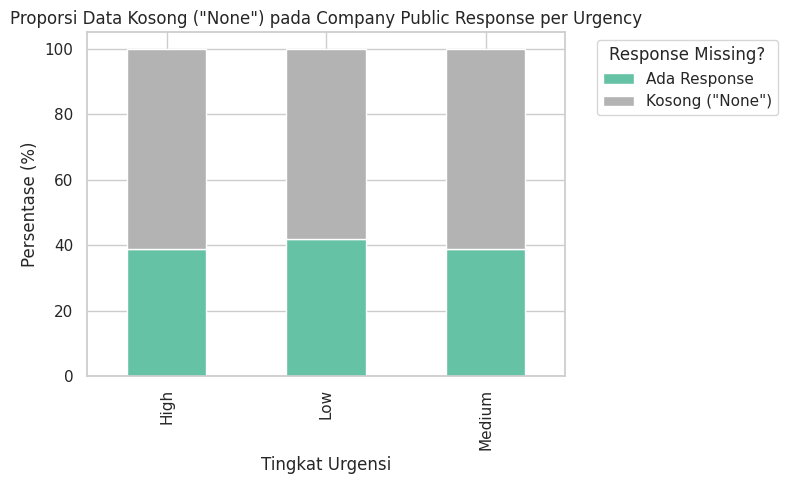

In [9]:
df['Response_Missing'] = df['Company public response'].isna() | (df['Company public response'] == 'None')
print("Membuat Plot EDA 1...")
missing_stats = df.groupby('Urgency')['Response_Missing'].value_counts(normalize=True).unstack() * 100
plt.figure(figsize=(8, 5))
missing_stats.plot(kind='bar', stacked=True, colormap='Set2', ax=plt.gca())
plt.title('Proporsi Data Kosong ("None") pada Company Public Response per Urgency')
plt.ylabel('Persentase (%)')
plt.xlabel('Tingkat Urgensi')
plt.legend(title='Response Missing?', labels=['Ada Response', 'Kosong ("None")'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


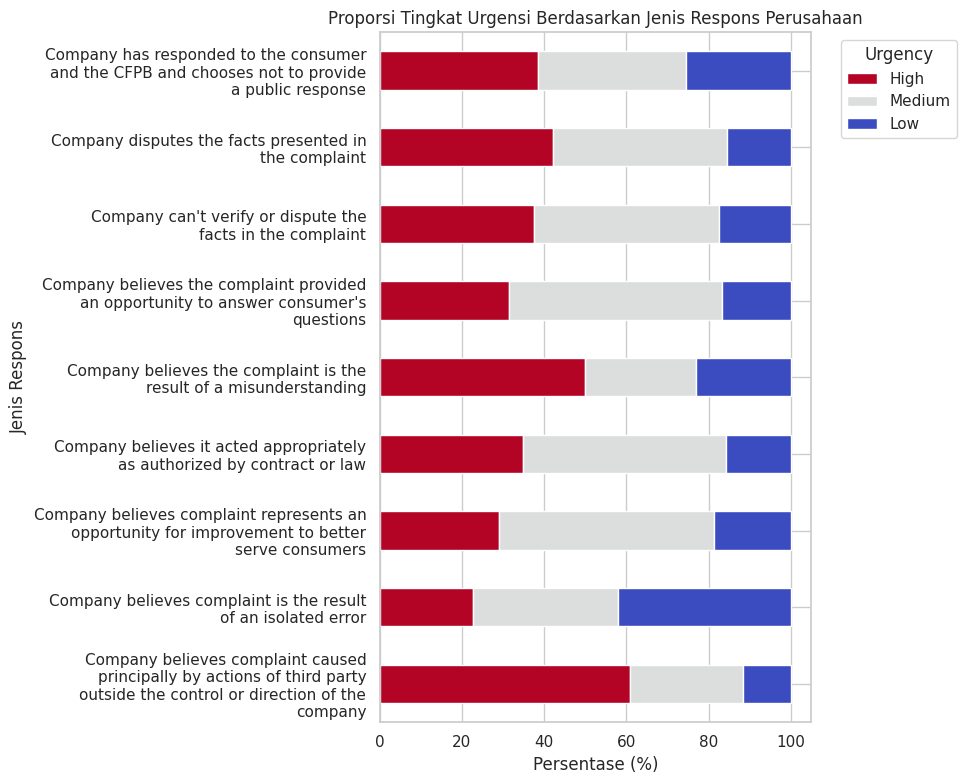

In [10]:
import textwrap
df_with_response = df[~df['Response_Missing']]
crosstab_response = pd.crosstab(df_with_response['Company public response'], df_with_response['Urgency'], normalize='index') * 100
if set(['High', 'Medium', 'Low']).issubset(crosstab_response.columns):
    crosstab_response = crosstab_response[['High', 'Medium', 'Low']]
plt.figure(figsize=(10, 8))
crosstab_response.plot(kind='barh', stacked=True, colormap='coolwarm_r', ax=plt.gca())
plt.title('Proporsi Tingkat Urgensi Berdasarkan Jenis Respons Perusahaan')
plt.xlabel('Persentase (%)')
plt.ylabel('Jenis Respons')
plt.legend(title='Urgency', bbox_to_anchor=(1.05, 1), loc='upper left')
ylabels = [textwrap.fill(label.get_text(), 40) for label in plt.gca().get_yticklabels()]
plt.gca().set_yticklabels(ylabels)
plt.tight_layout()


### EDA Urgency dengan kolom "Timely response"

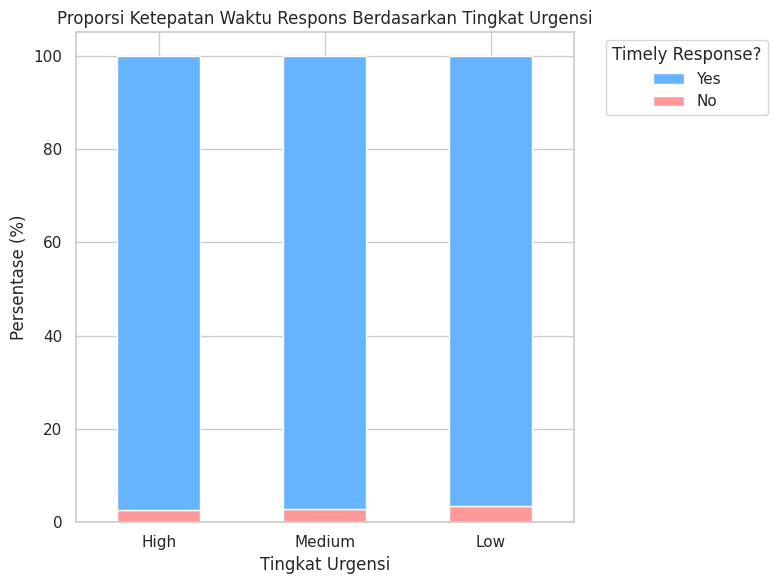

In [11]:
if 'Timely response?' in df.columns:
    # Buat tabel silang persentase antara Urgency dan Timely Response
    timely_urgency_stats = pd.crosstab(df['Urgency'], df['Timely response?'], normalize='index') * 100
    
    if set(['High', 'Medium', 'Low']).issubset(timely_urgency_stats.index):
        timely_urgency_stats = timely_urgency_stats.loc[['High', 'Medium', 'Low']]

    if set(['No', 'Yes']).issubset(timely_urgency_stats.columns):
        timely_urgency_stats = timely_urgency_stats[['No', 'Yes']]
        warna_custom = ['#ff9999', '#66b3ff'] 
    else:
        warna_custom = None
    plt.figure(figsize=(8, 6))
    timely_urgency_stats.plot(kind='bar', stacked=True, color=warna_custom, ax=plt.gca())
    plt.title('Proporsi Ketepatan Waktu Respons Berdasarkan Tingkat Urgensi')
    plt.ylabel('Persentase (%)')
    plt.xlabel('Tingkat Urgensi')
    
    plt.xticks(rotation=0)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(list(reversed(handles)), list(reversed(labels)), title='Timely Response?', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'Timely response?' tidak ditemukan di dataframe.")


/tmp/ipykernel_11039/408663744.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Urgency', y='Word Count', data=df, order=['High', 'Medium', 'Low'], palette='Set2')


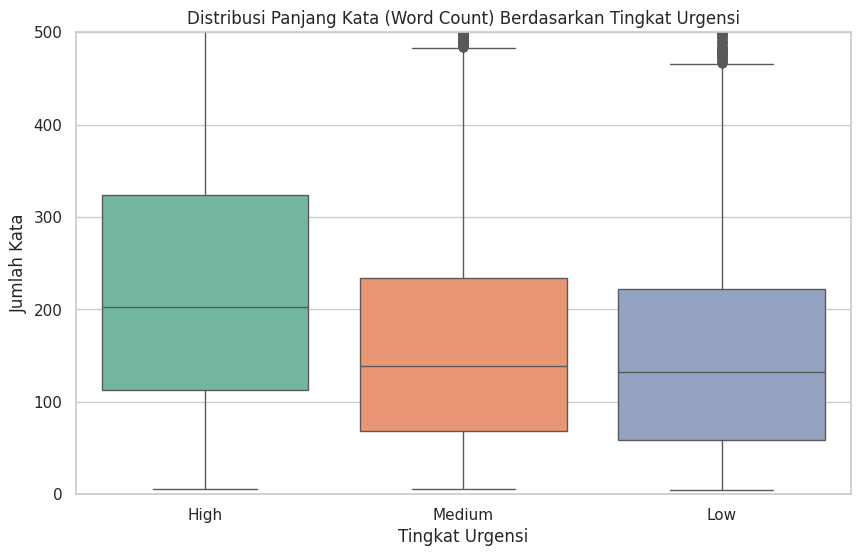

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Urgency', y='Word Count', data=df, order=['High', 'Medium', 'Low'], palette='Set2')
plt.title('Distribusi Panjang Kata (Word Count) Berdasarkan Tingkat Urgensi')
plt.ylim(0, 500) 
plt.ylabel('Jumlah Kata')
plt.xlabel('Tingkat Urgensi')
plt.show()

## 6. EDA (NLP Insights)

### Analisis N-Gram (Bigram)

Memproses Bigram Analysis...


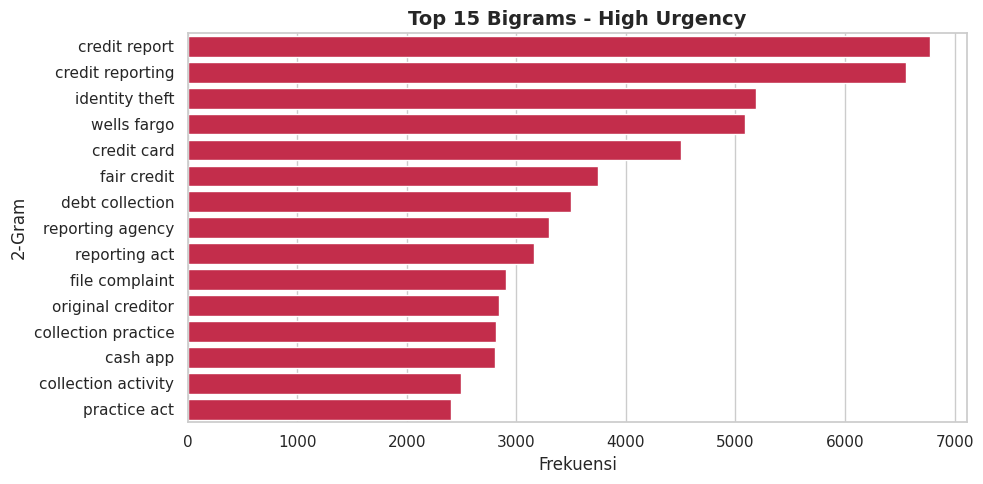

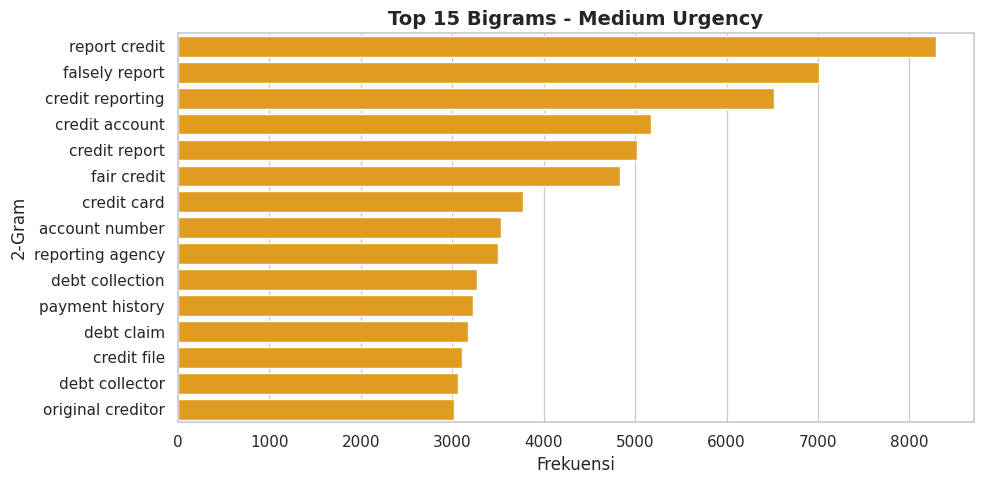

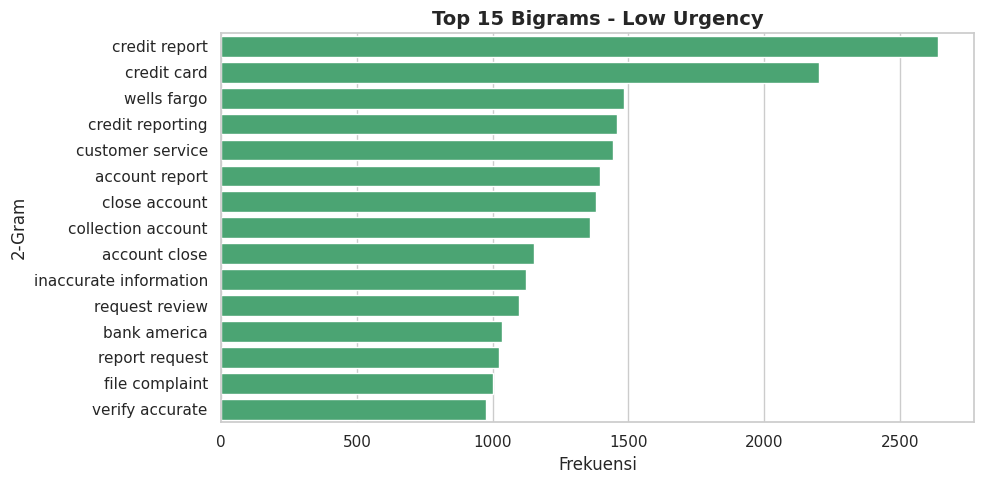

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Fungsi untuk mengekstrak dan memplot top N-Grams
def plot_top_ngrams(text_series, n, title, color):
    # Inisialisasi CountVectorizer untuk N-Gram (n=2 untuk Bigram)
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0) 
    
    # Mengurutkan frekuensi kata dari yang tertinggi
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:15]
    
    # Membuat DataFrame untuk visualisasi
    df_ngram = pd.DataFrame(words_freq, columns=['N-Gram', 'Frekuensi'])
    
    # Plotting menggunakan Seaborn
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Frekuensi', y='N-Gram', data=df_ngram, color=color)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Frekuensi', fontsize=12)
    plt.ylabel(f'{n}-Gram', fontsize=12)
    plt.tight_layout()
    plt.show()

# Memisahkan data berdasarkan kelas urgensi
high_texts = df[df['Urgency'] == 'High']['Cleaned_Narrative']
medium_texts = df[df['Urgency'] == 'Medium']['Cleaned_Narrative']
low_texts = df[df['Urgency'] == 'Low']['Cleaned_Narrative']

# Mengeksekusi fungsi untuk masing-masing kelas (Bigram / 2 kata)
print("Memproses Bigram Analysis...")
plot_top_ngrams(high_texts, 2, 'Top 15 Bigrams - High Urgency', 'crimson')
plot_top_ngrams(medium_texts, 2, 'Top 15 Bigrams - Medium Urgency', 'orange')
plot_top_ngrams(low_texts, 2, 'Top 15 Bigrams - Low Urgency', 'mediumseagreen')

### Word Cloud Tingkat Urgensi

Memproses Word Cloud...


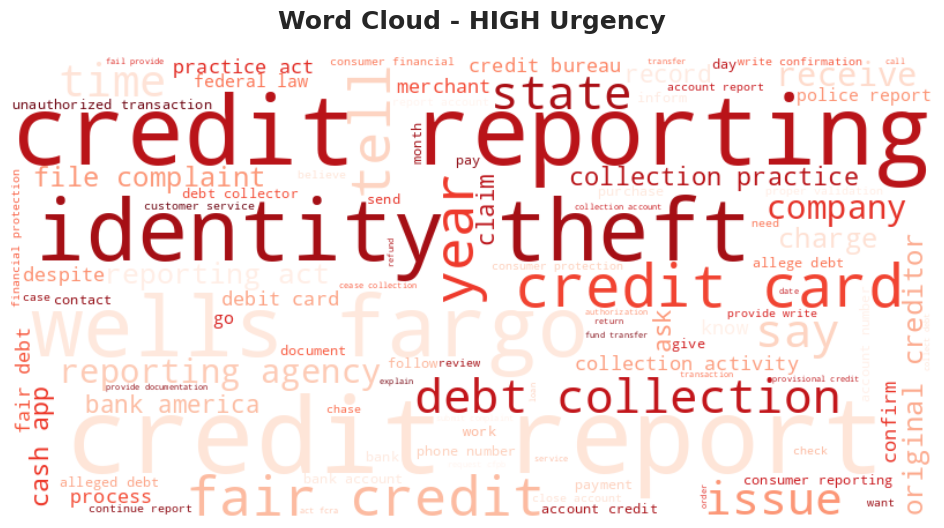

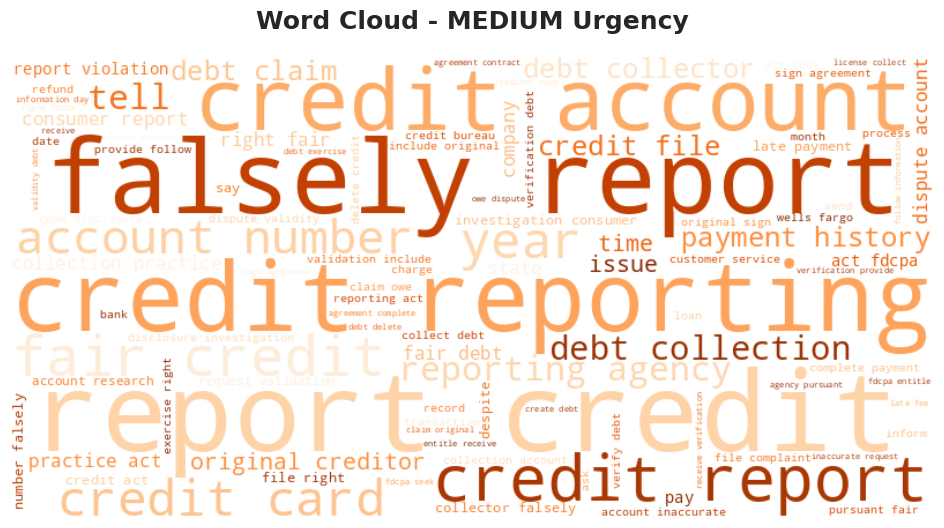

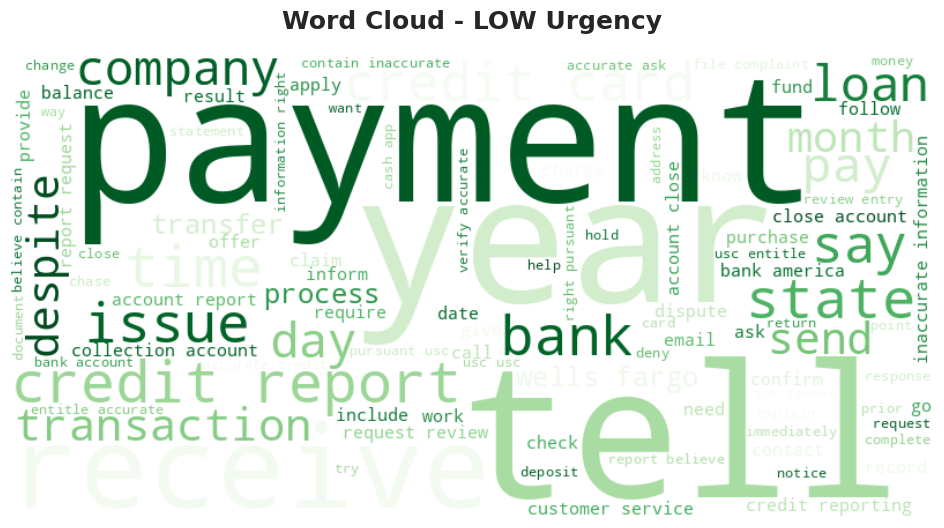

In [14]:
from wordcloud import WordCloud

# Fungsi untuk membuat dan memplot Word Cloud
def plot_wordcloud(text_series, title, colormap):
    # Menggabungkan semua baris teks menjadi satu paragraf raksasa
    text = " ".join(text_series.astype(str))
    
    # Membuat WordCloud dengan parameter visual
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          colormap=colormap, 
                          max_words=100,
                          contour_width=3, 
                          contour_color='steelblue').generate(text)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.show()

# Mengeksekusi Word Cloud dengan warna yang mencerminkan urgensi
print("Memproses Word Cloud...")
plot_wordcloud(high_texts, 'Word Cloud - HIGH Urgency', 'Reds')
plot_wordcloud(medium_texts, 'Word Cloud - MEDIUM Urgency', 'Oranges')
plot_wordcloud(low_texts, 'Word Cloud - LOW Urgency', 'Greens')

## 7. Menyimpan Data Bersih (Final Dataset)

In [15]:
# 1. Hapus baris kosong yang mungkin tersisa
df = df.dropna(subset=['Cleaned_Narrative', 'Raw_Filtered_Narrative'])

# 2. Pastikan teks tidak murni berisi spasi kosong pasca-pembersihan
df = df[df['Cleaned_Narrative'].str.strip() != '']

# 3. Sertakan KEDUA varian teks berserta label target
df_final = df[['Raw_Filtered_Narrative', 'Cleaned_Narrative', 'Urgency']].copy()

# 4. Ekspor dataset yang telah siap didistribusikan ke tim
df_final.to_csv('data/processed/cleaned_complaints.csv', index=False)

print(f"Dimensi dataset siap pakai: {df_final.shape}")
print(df_final.head(3))

Dimensi dataset siap pakai: (53927, 3)
                              Raw_Filtered_Narrative  \
0  i started getting emails and telephone calls f...   
1  date : // to : re : ref bal : {$1000.00} ep au...   
2  i was approached by a group of people outside ...   

                                   Cleaned_Narrative Urgency  
0  start get email telephone call company call bu...     Low  
1  date ref bal ep audit continue contact cease d...    High  
2  approach group people outside local grocery st...    High  
